#### Import & Configuration

In [1]:
!pip install sentence-transformers torch transformers scikit-learn numpy pandas matplotlib seaborn tqdm accelerate --quiet

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

TARGET_DIM      = 128
MODEL_NAME      = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
BATCH_SIZE      = 64
FINETUNE_EPOCHS = 3
FINETUNE_LR     = 2e-5
WARMUP_RATIO    = 0.1


W_DIM    = 0.4
W_COSINE = 0.6
MAX_DIM  = 768

def assignment_score(dim, cosine_sim):
    """Assignment scoring formula: 0.4*(1 - dim/768) + 0.6*cosine."""
    return W_DIM * (1 - dim / MAX_DIM) + W_COSINE * cosine_sim

print(f"\nScoring preview at dim={TARGET_DIM}:")
for cs in [0.70, 0.75, 0.80, 0.85, 0.90]:
    print(f"  cosine={cs:.2f}  ->  score={assignment_score(TARGET_DIM, cs):.4f}")

Using device: cuda

Scoring preview at dim=128:
  cosine=0.70  ->  score=0.7533
  cosine=0.75  ->  score=0.7833
  cosine=0.80  ->  score=0.8133
  cosine=0.85  ->  score=0.8433
  cosine=0.90  ->  score=0.8733


#### Load Data

In [11]:
def load_data(split: str):


    suffix = '_10000' if split == 'train' else '_1000'
    sa_path = f"{split}_sa{suffix}.csv"
    en_path = f"{split}_en{suffix}.csv"

    if not os.path.exists(sa_path) or not os.path.exists(en_path):
        raise FileNotFoundError(
            f"Missing: {sa_path!r} or {en_path!r}.\n"
            "Download the dataset and place CSV files in the working directory."
        )

    df_sa = pd.read_csv(sa_path)
    df_en = pd.read_csv(en_path)


    merge_col = 'Source_id'
    df = pd.merge(df_sa, df_en, on=merge_col, suffixes=('_sa', '_en'))


    sa_col = 'Sentence_sa'
    en_col = 'Sentence_en'


    df = df.dropna(subset=[sa_col, en_col])
    df[sa_col] = df[sa_col].astype(str).str.strip()
    df[en_col] = df[en_col].astype(str).str.strip()
    df = df[(df[sa_col] != '') & (df[en_col] != '')].reset_index(drop=True)

    print(f"[{split:5s}] {len(df):>5} aligned pairs  |  SA col: '{sa_col}'  |  EN col: '{en_col}'")
    return df, sa_col, en_col


try:
    train_df, sa_col, en_col = load_data('train')
    dev_df,   _,      _     = load_data('dev')
    test_df,  _,      _     = load_data('test')

    print(f"\nTotals -- Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}")
    print("\nSample (first 3 train pairs):")
    display(train_df[[sa_col, en_col]].head(3))


    print("\nWord-length statistics:")
    for name, df in [('Train', train_df), ('Dev', dev_df), ('Test', test_df)]:
        sa_lens = df[sa_col].str.split().str.len()
        en_lens = df[en_col].str.split().str.len()
        print(f"  [{name}] SA: {sa_lens.mean():.1f} +/- {sa_lens.std():.1f} words | "
              f"EN: {en_lens.mean():.1f} +/- {en_lens.std():.1f} words")

except FileNotFoundError as e:
    print(f"ERROR: {e}")

[train] 10000 aligned pairs  |  SA col: 'Sentence_sa'  |  EN col: 'Sentence_en'
[dev  ]  1000 aligned pairs  |  SA col: 'Sentence_sa'  |  EN col: 'Sentence_en'
[test ]  1000 aligned pairs  |  SA col: 'Sentence_sa'  |  EN col: 'Sentence_en'

Totals -- Train: 10000 | Dev: 1000 | Test: 1000

Sample (first 3 train pairs):


,Sentence_sa,Sentence_en
0,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."



Word-length statistics:
  [Train] SA: 9.7 +/- 5.5 words | EN: 12.6 +/- 8.0 words
  [Dev] SA: 9.4 +/- 5.1 words | EN: 12.2 +/- 7.5 words
  [Test] SA: 9.4 +/- 5.1 words | EN: 12.3 +/- 7.5 words


#### Loading MLM

In [5]:
model = SentenceTransformer(MODEL_NAME, device=DEVICE)
native_dim = model.get_sentence_embedding_dimension()
print(f"Model loaded. Native embedding dim: {native_dim}")
print(f"Compression ratio: {native_dim} -> {TARGET_DIM} ({TARGET_DIM/native_dim*100:.1f}% retained)")

Loading: sentence-transformers/paraphrase-multilingual-mpnet-base-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded. Native embedding dim: 768
Compression ratio: 768 -> 128 (16.7% retained)


#### Baseline Evaluation

In [12]:
def encode_sentences(mdl, sentences, batch_size=64, desc='Encoding'):
    """Encode sentences to numpy embeddings (not L2-normalized)."""
    return mdl.encode(
        sentences,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False
    )


def apply_pca_and_normalize(pca_model, emb):
    """Project embeddings with a fitted PCA and L2-normalize."""
    return normalize(pca_model.transform(emb), norm='l2')


def compute_cosine_stats(sa_emb, en_emb):
    """Compute paired cosine similarities. Inputs must be L2-normalized."""
    sims = np.sum(sa_emb * en_emb, axis=1)
    return sims, sims.mean(), sims.std()

print("Baseline: encoding dev set...")
baseline_sa_raw = encode_sentences(model, dev_df[sa_col].tolist(), desc='Baseline SA')
baseline_en_raw = encode_sentences(model, dev_df[en_col].tolist(), desc='Baseline EN')


baseline_pca = PCA(n_components=TARGET_DIM, random_state=SEED)
baseline_pca.fit(np.vstack([baseline_sa_raw, baseline_en_raw]))

baseline_sa = apply_pca_and_normalize(baseline_pca, baseline_sa_raw)
baseline_en = apply_pca_and_normalize(baseline_pca, baseline_en_raw)

_, baseline_avg, baseline_std = compute_cosine_stats(baseline_sa, baseline_en)
print(f"\nBaseline (no FT, PCA->{TARGET_DIM}):")
print(f"  Dev cosine        : {baseline_avg:.4f} +/- {baseline_std:.4f}")
print(f"  Assignment score  : {assignment_score(TARGET_DIM, baseline_avg):.4f}")

Baseline: encoding dev set...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Baseline (no FT, PCA->128):
  Dev cosine        : 0.4161 +/- 0.2463
  Assignment score  : 0.5830


In [ ]:
def make_input_examples(df, sa_col, en_col):
    """Convert aligned dataframe rows to InputExample objects."""
    return [InputExample(texts=[str(r[sa_col]), str(r[en_col])]) for _, r in df.iterrows()]


train_examples   = make_input_examples(train_df, sa_col, en_col)
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)
train_loss       = losses.MultipleNegativesRankingLoss(model)

evaluator = evaluation.EmbeddingSimilarityEvaluator(
    dev_df[sa_col].tolist(),
    dev_df[en_col].tolist(),
    [1.0] * len(dev_df),
    batch_size=BATCH_SIZE,
    name='dev-cosine',
)

total_steps  = len(train_dataloader) * FINETUNE_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
print(f"Fine-tuning config:")
print(f"  Epochs       : {FINETUNE_EPOCHS}")
print(f"  Total steps  : {total_steps}")
print(f"  Warmup steps : {warmup_steps}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  LR           : {FINETUNE_LR}")

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=FINETUNE_EPOCHS,
    warmup_steps=warmup_steps,
    optimizer_params={'lr': FINETUNE_LR},
    output_path='./finetuned_model',
    save_best_model=True,
    show_progress_bar=True,
)
print("\nFine-tuning complete. Best model saved to ./finetuned_model")

In [9]:
df_sa_train = pd.read_csv('/content/train_sa_10000.csv')
print(df_sa_train.columns)

Index(['Source_id', 'Sentence_sa'], dtype='object')


In [10]:
df_en_train = pd.read_csv('/content/train_en_10000.csv')
print(df_en_train.columns)

Index(['Source_id', 'Sentence_en'], dtype='object')


####  Encode All Splits with Fine-tuned Model

In [15]:
best_model = SentenceTransformer('./finetuned_model', device=DEVICE)
print(f"Fine-tuned model loaded. Native dim: {best_model.get_sentence_embedding_dimension()}")

print("\nEncoding all splits...")
splits_map = {'train': train_df, 'dev': dev_df, 'test': test_df}
raw_embs = {}
for split_name, df in splits_map.items():
    raw_embs[f'{split_name}_sa'] = encode_sentences(best_model, df[sa_col].tolist(), desc=f'{split_name} SA')
    raw_embs[f'{split_name}_en'] = encode_sentences(best_model, df[en_col].tolist(), desc=f'{split_name} EN')

print(f"\nRaw shapes: SA={raw_embs['train_sa'].shape}, EN={raw_embs['train_en'].shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded. Native dim: 768

Encoding all splits...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Raw shapes: SA=(10000, 768), EN=(10000, 768)


#### Dimensionality Reduction Using PCA

PCA fitted on 20,000 vectors.
Explained variance with 128 components: 85.31%


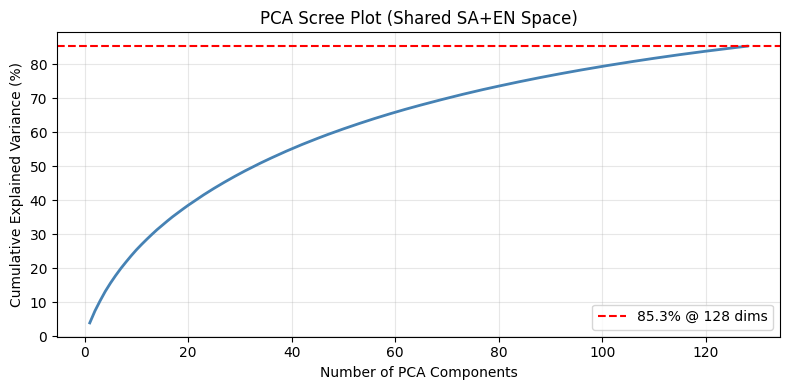


Final embedding shapes: SA=(1000, 128), EN=(1000, 128)


In [16]:
all_train = np.vstack([raw_embs['train_sa'], raw_embs['train_en']])
pca = PCA(n_components=TARGET_DIM, random_state=SEED)
pca.fit(all_train)

explained_var = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA fitted on {len(all_train):,} vectors.")
print(f"Explained variance with {TARGET_DIM} components: {explained_var:.2f}%")

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, TARGET_DIM + 1), cumvar, color='steelblue', lw=2)
ax.axhline(explained_var, color='red', ls='--', lw=1.5,
           label=f'{explained_var:.1f}% @ {TARGET_DIM} dims')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA Scree Plot (Shared SA+EN Space)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()


embs = {key: apply_pca_and_normalize(pca, raw) for key, raw in raw_embs.items()}

print(f"\nFinal embedding shapes: SA={embs['test_sa'].shape}, EN={embs['test_en'].shape}")

In [17]:
def evaluate_retrieval(sa_emb, en_emb, ks=(1, 5, 10)):

    sim_matrix = sa_emb @ en_emb.T  # (N, N) pairwise cosine (L2-normed)
    results = {}
    for k in ks:
        topk = np.argsort(-sim_matrix, axis=1)[:, :k]
        hit  = np.array([i in topk[i] for i in range(len(sa_emb))])
        results[f'P@{k}'] = hit.mean()
    return results


def full_evaluate(sa_emb, en_emb, split_name):
    sims, avg, std = compute_cosine_stats(sa_emb, en_emb)
    retrieval = evaluate_retrieval(sa_emb, en_emb)
    ascore = assignment_score(TARGET_DIM, avg)

    print(f"\n{'─'*58}")
    print(f"  {split_name} Results")
    print(f"{'─'*58}")
    print(f"  Avg cosine similarity : {avg:.4f} +/- {std:.4f}")
    print(f"  Min / Max             : {sims.min():.4f} / {sims.max():.4f}")
    for k_label, v in retrieval.items():
        print(f"  {k_label} retrieval          : {v*100:.1f}%")
    print(f"  Assignment score      : {ascore:.4f}")
    return sims, avg


dev_sims,  dev_avg  = full_evaluate(embs['dev_sa'],  embs['dev_en'],  'Dev')
test_sims, test_avg = full_evaluate(embs['test_sa'], embs['test_en'], 'Test')

print(f"\n{'='*58}")
print(f"  Ablation Summary")
print(f"{'='*58}")
print(f"  Baseline  (no FT, PCA->{TARGET_DIM}) : cosine={baseline_avg:.4f}  score={assignment_score(TARGET_DIM, baseline_avg):.4f}")
print(f"  Fine-tuned (FT,  PCA->{TARGET_DIM}) : cosine={dev_avg:.4f}  score={assignment_score(TARGET_DIM, dev_avg):.4f}")
print(f"  Delta cosine improvement           : +{dev_avg - baseline_avg:.4f}")


──────────────────────────────────────────────────────────
  Dev Results
──────────────────────────────────────────────────────────
  Avg cosine similarity : 0.7260 +/- 0.1609
  Min / Max             : 0.0600 / 1.0000
  P@1 retrieval          : 88.5%
  P@5 retrieval          : 97.1%
  P@10 retrieval          : 98.0%
  Assignment score      : 0.7689

──────────────────────────────────────────────────────────
  Test Results
──────────────────────────────────────────────────────────
  Avg cosine similarity : 0.7237 +/- 0.1542
  Min / Max             : -0.1580 / 1.0000
  P@1 retrieval          : 87.7%
  P@5 retrieval          : 96.9%
  P@10 retrieval          : 98.2%
  Assignment score      : 0.7676

  Ablation Summary
  Baseline  (no FT, PCA->128) : cosine=0.4161  score=0.5830
  Fine-tuned (FT,  PCA->128) : cosine=0.7260  score=0.7689
  Delta cosine improvement           : +0.3099


#### t-SNE Visualization

Running t-SNE ...


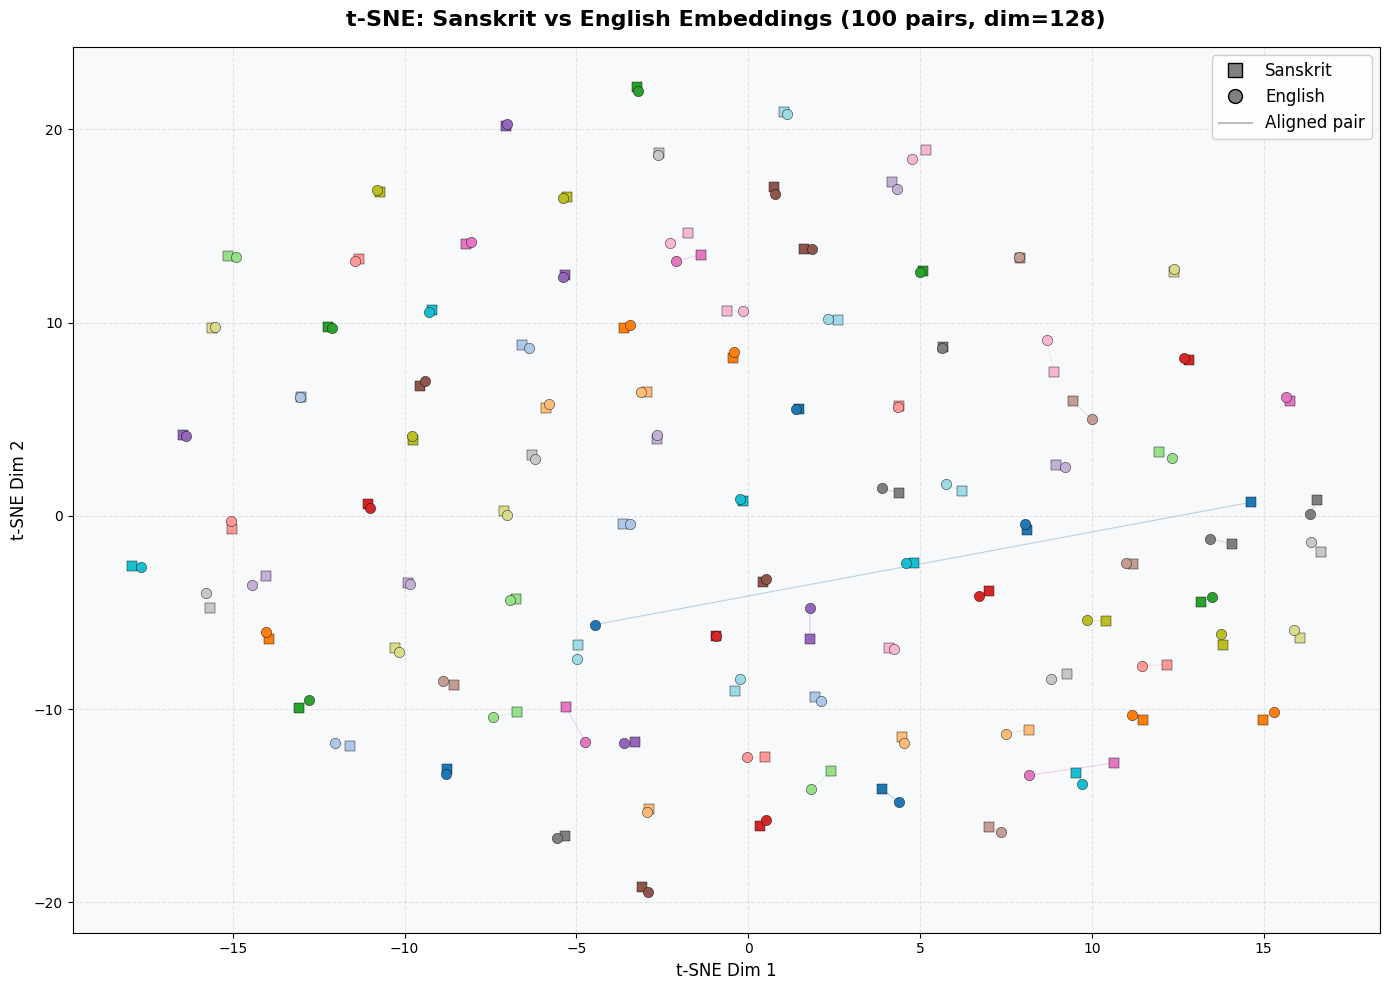

Saved: tsne_visualization.png


In [18]:
def plot_tsne(sa_emb, en_emb, n_samples=100,
              title='t-SNE: Sanskrit vs English', save_path='tsne.png'):

    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(sa_emb), size=min(n_samples, len(sa_emb)), replace=False)
    combined = np.vstack([sa_emb[idx], en_emb[idx]])   # (2N, D)

    print("Running t-SNE ...")
    coords = TSNE(
        n_components=2, perplexity=30, n_iter=2000,
        learning_rate='auto', init='pca', random_state=SEED
    ).fit_transform(combined)

    n = len(idx)
    sa_c, en_c = coords[:n], coords[n:]
    colors = cm.tab20(np.linspace(0, 1, n))

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_facecolor('#f8f9fa')
    for i in range(n):
        c = colors[i]
        ax.plot([sa_c[i, 0], en_c[i, 0]], [sa_c[i, 1], en_c[i, 1]],
                color=c, alpha=0.3, lw=0.8, zorder=1)
        ax.scatter(*sa_c[i], color=c, marker='s', s=55, zorder=3,
                   edgecolors='black', linewidths=0.3)
        ax.scatter(*en_c[i], color=c, marker='o', s=55, zorder=3,
                   edgecolors='black', linewidths=0.3)

    legend_elements = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
               markersize=10, markeredgecolor='black', label='Sanskrit'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=10, markeredgecolor='black', label='English'),
        Line2D([0], [0], color='gray', alpha=0.5, lw=1.5, label='Aligned pair'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=12, framealpha=0.9)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('t-SNE Dim 1', fontsize=12)
    ax.set_ylabel('t-SNE Dim 2', fontsize=12)
    ax.grid(True, alpha=0.3, ls='--')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


plot_tsne(
    embs['dev_sa'], embs['dev_en'], n_samples=100,
    title=f't-SNE: Sanskrit vs English Embeddings (100 pairs, dim={TARGET_DIM})',
    save_path='tsne_visualization.png',
)

--- DEV SET: Qualitative Analysis ---


,Type,Cosine,Sanskrit,English
0,High,1.0000,अध्यापकः कृष्णफलके लिखति ।,अध्यापकः कृष्णफलके लिखति ।
1,High,1.0000,अध्यापकः पुस्तकं गृहीत्वा लिखति ।,अध्यापकः पुस्तकं गृहीत्वा लिखति ।
2,High,1.0000,सीता रामाय सन्देशं प्रेषयति ।,सीता रामाय सन्देशं प्रेषयति ।
3,High,1.0000,श्रीकृष्णः उपायं चिन्तयति ।,श्रीकृष्णः उपायं चिन्तयति ।
4,High,1.0000,श्रीकृष्णः भीष्पप्रतिज्ञां ज्ञात्वा उपायं चिन्...,श्रीकृष्णः भीष्पप्रतिज्ञां ज्ञात्वा उपायं चिन्...
5,Low,0.0600,यतः सकलदेशस्य दीप्तये दीप्तिरूपकं।,"""For mine eyes have seen thy salvation,"""
6,Low,0.0726,इत्यादीनि ओपरेशन्स् अस्मिन् ट्युटोरियल् मध्ये ...,how to print the processed output and using re...
7,Low,0.0988,य: समस्त-संसारे सम्मानं प्राप्तं करोति।,What once prevailed centuries ago still rules ...
8,Low,0.1189,अनेन सरलतया तस्य समक्षे उत्थाय स्व चित्रं निर्...,"""In particular, easels are traditionally used ..."
9,Low,0.1271,नाम्नैव स्पष्टोऽस्ति यत एतेषआं प्रकृति: कोमला ...,"""Komal means soft and swar means """"note"""""""


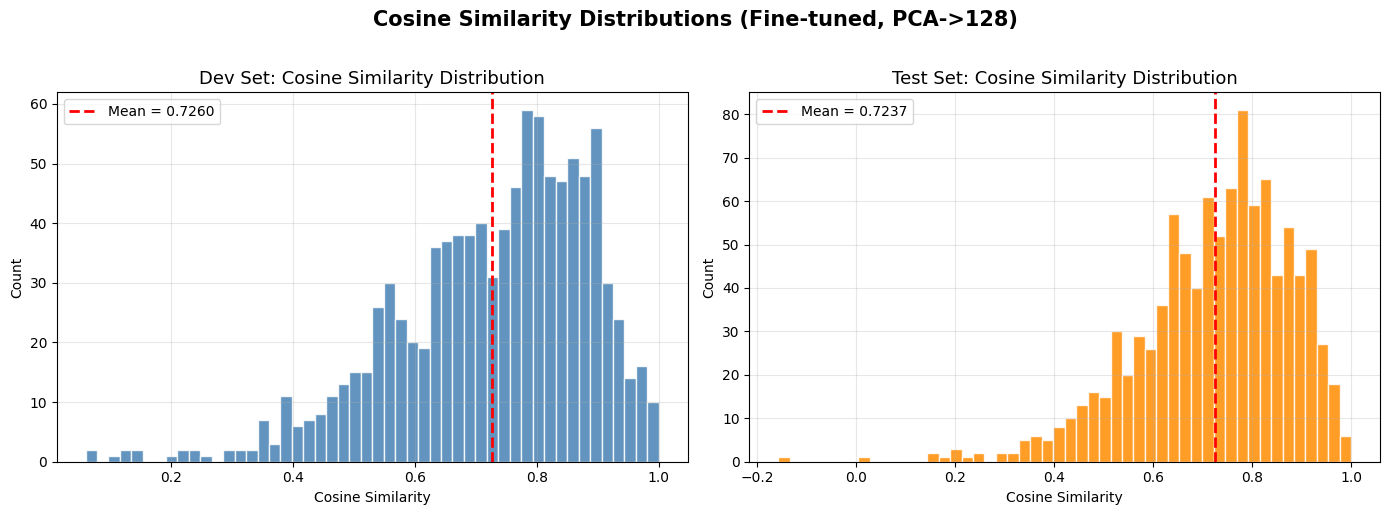

Distribution plot saved.


In [19]:
def qualitative_analysis(df, sa_emb, en_emb, sa_col, en_col, n_each=5):
    """
    Show top-n and bottom-n pairs by cosine similarity.
    Useful for understanding what the model gets right and wrong.
    """
    sims = np.sum(sa_emb * en_emb, axis=1)
    top_idx    = np.argsort(sims)[-n_each:][::-1]
    bottom_idx = np.argsort(sims)[:n_each]

    rows = []
    for label, idxs in [('High', top_idx), ('Low', bottom_idx)]:
        for idx in idxs:
            rows.append({
                'Type':     label,
                'Cosine':   round(float(sims[idx]), 4),
                'Sanskrit': df.iloc[idx][sa_col][:80],
                'English':  df.iloc[idx][en_col][:80],
            })

    result_df = pd.DataFrame(rows)
    display(result_df)
    return result_df, sims


print("--- DEV SET: Qualitative Analysis ---")
analysis_df, _ = qualitative_analysis(dev_df, embs['dev_sa'], embs['dev_en'], sa_col, en_col)

# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sims, avg, color, split_name in [
    (axes[0], dev_sims,  dev_avg,  'steelblue',  'Dev'),
    (axes[1], test_sims, test_avg, 'darkorange', 'Test'),
]:
    ax.hist(sims, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(avg, color='red', ls='--', lw=2, label=f'Mean = {avg:.4f}')
    ax.set_title(f'{split_name} Set: Cosine Similarity Distribution', fontsize=13)
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Cosine Similarity Distributions (Fine-tuned, PCA->{TARGET_DIM})',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cosine_similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution plot saved.")

#### Cross-lingual Retrieval Heatmap

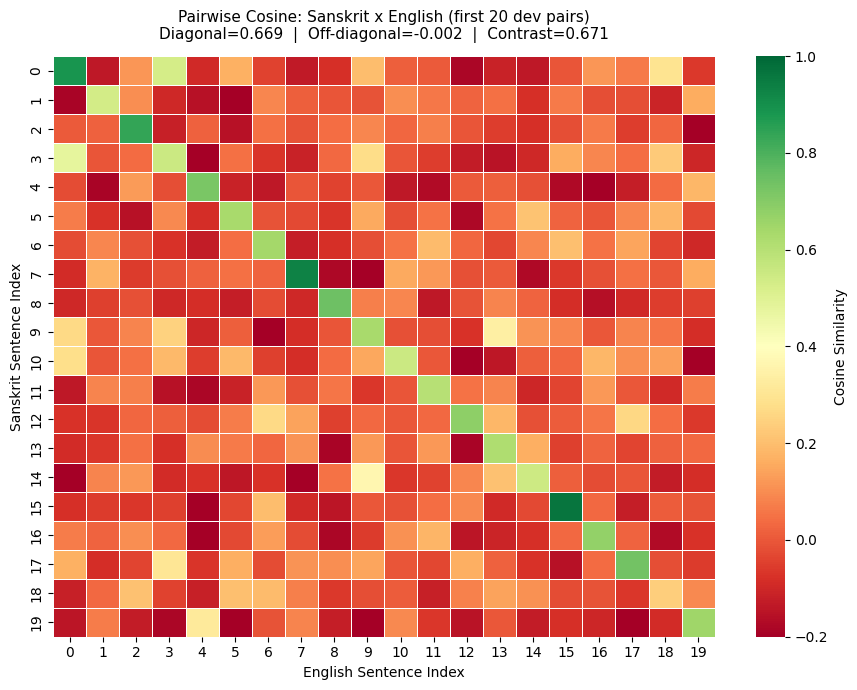

Heatmap saved. Diagonal vs off-diagonal contrast: 0.6714


In [20]:
N_HEAT = 20
sa_heat = embs['dev_sa'][:N_HEAT]
en_heat = embs['dev_en'][:N_HEAT]
heat_matrix = sa_heat @ en_heat.T   # (N, N)

diag_mean    = np.diag(heat_matrix).mean()
offdiag_mean = (heat_matrix.sum() - np.trace(heat_matrix)) / (N_HEAT * (N_HEAT - 1))
contrast     = diag_mean - offdiag_mean

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    heat_matrix, ax=ax,
    cmap='RdYlGn', vmin=-0.2, vmax=1.0,
    annot=(N_HEAT <= 15), fmt='.2f', linewidths=0.5,
    cbar_kws={'label': 'Cosine Similarity'},
)
ax.set_title(
    f'Pairwise Cosine: Sanskrit x English (first {N_HEAT} dev pairs)\n'
    f'Diagonal={diag_mean:.3f}  |  Off-diagonal={offdiag_mean:.3f}  |  Contrast={contrast:.3f}',
    fontsize=11, pad=12
)
ax.set_xlabel('English Sentence Index')
ax.set_ylabel('Sanskrit Sentence Index')
plt.tight_layout()
plt.savefig('cosine_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Heatmap saved. Diagonal vs off-diagonal contrast: {contrast:.4f}")

In [23]:
test_sa_emb = embs['test_sa']
test_en_emb = embs['test_en']

assert test_sa_emb.shape == test_en_emb.shape, \
    f"Shape mismatch: SA={test_sa_emb.shape} vs EN={test_en_emb.shape}"
assert test_sa_emb.shape[1] == TARGET_DIM, \
    f"Dim mismatch: expected {TARGET_DIM}, got {test_sa_emb.shape[1]}"
assert np.allclose(np.linalg.norm(test_sa_emb, axis=1), 1.0, atol=1e-5), \
    "SA embeddings are not L2-normalized!"
assert np.allclose(np.linalg.norm(test_en_emb, axis=1), 1.0, atol=1e-5), \
    "EN embeddings are not L2-normalized!"

np.save('sa_embeddings.npy', test_sa_emb)
np.save('en_embeddings.npy', test_en_emb)

assert np.allclose(np.load('sa_embeddings.npy'), test_sa_emb), "SA reload mismatch!"
assert np.allclose(np.load('en_embeddings.npy'), test_en_emb), "EN reload mismatch!"

print("checkmark sa_embeddings.npy  -- saved and verified")
print("checkmark en_embeddings.npy  -- saved and verified")
print()

print("Final Summary")

print(f"  Model            : {MODEL_NAME} (fine-tuned)")
print(f"  Embedding dim    : {TARGET_DIM}")
print(f"  Dev  cosine      : {dev_avg:.4f}")
print(f"  Test cosine      : {test_avg:.4f}")
print(f"  Assignment score : {assignment_score(TARGET_DIM, test_avg):.4f}")

checkmark sa_embeddings.npy  -- saved and verified
checkmark en_embeddings.npy  -- saved and verified

Final Summary
  Model            : sentence-transformers/paraphrase-multilingual-mpnet-base-v2 (fine-tuned)
  Embedding dim    : 128
  Dev  cosine      : 0.7260
  Test cosine      : 0.7237
  Assignment score : 0.7676


In [25]:
import numpy as np
data_en = np.load('/content/sa_embeddings.npy')
print(data_en)



[[ 0.01858382  0.2820835   0.19428839 ... -0.04309585  0.00450641
   0.00907383]
 [-0.20281617 -0.22161454  0.02719168 ...  0.01844797  0.01740037
  -0.09634146]
 [-0.18495767  0.26953402 -0.21557745 ...  0.02930259 -0.01523239
   0.04869225]
 ...
 [-0.00420618  0.18639573 -0.13968246 ...  0.01767328  0.04765431
   0.05266954]
 [-0.3642772   0.03283133  0.17499062 ...  0.05099103  0.03162672
  -0.07555007]
 [ 0.03668589 -0.32442993  0.10033583 ... -0.02370463 -0.05086622
  -0.0322818 ]]
